# Finance Arena v0.5
Ridge ensemble specialists + final meta-learner regressor, with only essential research steps.

In [66]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
from numerapi import NumerAPI
from dotenv import load_dotenv
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")

_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

from utils.metrics import calculate_metrics
from utils.visualization import display_metrics_table
from utils.model_benchmark import record_model_metrics, compare_top_models_with_current

load_dotenv()
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1) Data and Targets

In [67]:
napi = NumerAPI(
    public_id=os.getenv("NAPI_PUBLIC_ID_UPLOAD"),
    secret_key=os.getenv("NAPI_SECRET_KEY_UPLOAD"),
)

DATA_VERSION = "v5.2"
DATA_DIR = "../../data"
os.makedirs(DATA_DIR, exist_ok=True)

features_path = os.path.join(DATA_DIR, DATA_VERSION, "features.json")
if not os.path.exists(features_path):
    napi.download_dataset(
        f"{DATA_VERSION}/features.json",
        dest_path=features_path,
    )

feature_metadata = json.load(open(features_path))
feature_set = feature_metadata["feature_sets"]["small"]

MAIN_TARGET = "target_ender_20"
EMBARGO_ERAS = 4

snnr_df = pd.read_csv("../../exploratory_notebooks/snnr_weights_vs_correlation_v5.2.csv")
AUXILIARY_TARGETS = snnr_df["auxiliary_target"].tolist()
ALL_TARGETS = [MAIN_TARGET] + AUXILIARY_TARGETS

columns_to_load = ["era"] + feature_set + ALL_TARGETS
train = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "train.parquet"), columns=columns_to_load)
validation = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"), columns=columns_to_load)
live = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "live.parquet"), columns=["era"] + feature_set)
val_benchmarks = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet"))

last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in range(last_train_era + 1, last_train_era + 1 + EMBARGO_ERAS)]
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

print("Train shape     :", train.shape)
print("Validation shape:", validation.shape)
print("Live shape      :", live.shape)
print("Aux targets     :", len(AUXILIARY_TARGETS))

Train shape     : (2746268, 61)
Validation shape: (3921307, 61)
Live shape      : (7128, 43)
Aux targets     : 17


## 2) Ridge Specialists

In [68]:
def rank_by_era(values, eras):
    tmp = pd.DataFrame({
        "era": eras.values,
        "value": np.asarray(values, dtype=float),
    })
    return tmp.groupby("era")["value"].rank(pct=True, method="first").values


def neutralize_predictions_by_era(preds, eras, features_df, feature_cols, proportion=0.5):
    tmp = pd.DataFrame({
        "era": eras.values,
        "prediction": np.asarray(preds, dtype=float),
    }, index=features_df.index)
    tmp = tmp.join(features_df[feature_cols])

    def _neutralize_block(block):
        scores = block["prediction"].values
        exposures = block[feature_cols].values
        scores = scores - scores.mean()
        exposures = exposures - exposures.mean(axis=0)
        correction = exposures.dot(np.linalg.pinv(exposures).dot(scores))
        return pd.Series(scores - proportion * correction, index=block.index)

    neutralized = tmp.groupby("era", group_keys=False).apply(_neutralize_block)
    return neutralized.groupby(tmp["era"]).rank(pct=True, method="first").values

In [69]:
# Training the ridge regression specialists for auxiliary targets
import tqdm

TARGETS_TO_TRAIN = [t for t in AUXILIARY_TARGETS if t in train.columns and t != MAIN_TARGET]
print("Training specialists on targets:", len(TARGETS_TO_TRAIN))

train_clean = train.dropna(subset=TARGETS_TO_TRAIN)
validation_clean = validation.dropna(subset=TARGETS_TO_TRAIN)
print("Training data after dropping rows with NaN in target columns:", train_clean.shape)
print("Validation data after dropping rows with NaN in target columns:", validation_clean.shape)

models_dictionary = {}
model_predictions = {}

# One Ridge regression specialist per auxiliary target
for target_name in tqdm.tqdm(TARGETS_TO_TRAIN):
    _clean_train_df = train_clean[feature_set + [target_name]]
    _X_train = _clean_train_df[feature_set].values
    _y_train = _clean_train_df[target_name].values
    
    # Train model on the entire training data for this target
    model = Ridge(alpha=1.0e-6, random_state=42)
    model.fit(_X_train, _y_train)
    
    _clean_val_df = validation_clean[['era'] + feature_set + [target_name]]
    _X_val = _clean_val_df[feature_set].values
    _y_val = _clean_val_df[target_name].values
    
    val_preds = model.predict(_X_val)
    
    model_name = f"{target_name}"
    models_dictionary[model_name] = model
    
    model_predictions[model_name] = {
        "validation_predictions": val_preds,
        "true": _y_val,
        "eras": _clean_val_df["era"].values,
    }

Training specialists on targets: 17
Training data after dropping rows with NaN in target columns: (2732873, 61)
Validation data after dropping rows with NaN in target columns: (3812459, 61)


100%|██████████| 17/17 [00:18<00:00,  1.08s/it]


In [70]:
# Evaluate the perforamnce of the specialists on the validation set MSE and R2 metrics
model_metrics = {}
for model_name, preds_dict in model_predictions.items():
    val_preds = preds_dict["validation_predictions"]
    true_vals = preds_dict["true"]
    
    mse = mean_squared_error(true_vals, val_preds)
    r2 = r2_score(true_vals, val_preds)
    
    model_metrics[model_name] = {
        "MSE": mse,
        "R2": r2,
    }

# Assert the length of the predictions is the same for all models and matches the length of the true values
num_predictions = len(next(iter(model_predictions.values()))["validation_predictions"])
for model_name, preds_dict in model_predictions.items():
    assert len(preds_dict["validation_predictions"]) == num_predictions, f"Model {model_name} has a different number of predictions"
    assert len(preds_dict["true"]) == num_predictions, f"Model {model_name} has a different number of true values"

# Display the metrics in a table
metrics_df = pd.DataFrame(model_metrics).T
display(metrics_df)

,MSE,R2
target_jasper_20,0.050058,-0.000151
target_teager2b_20,0.050054,-0.000095
target_claudia_20,0.049480,-0.000094
target_rowan_20,0.050071,-0.000105
target_waldo_20,0.049914,-0.000356
target_ender_60,0.050077,-0.000166
target_xerxes_20,0.049836,-0.000280
target_jeremy_20,0.050008,-0.000439
target_cyrusd_20,0.049868,-0.000284
target_agnes_20,0.049768,-0.000333


## 3) Ridge Ensemble and Meta Learner

In [71]:
# 3.1) Prepare Meta-Features for the Meta-Learner
# We use the validation predictions of our specialists as features for the meta-learner.

meta_X = pd.DataFrame({
    name: d["validation_predictions"] for name, d in model_predictions.items()
})
meta_y = pd.Series(validation_clean[MAIN_TARGET].values, index=validation_clean.index)

# 70 - 30 train-val split for the meta-learner
split_index = int(0.7 * len(meta_X))
meta_X_train, meta_X_val = meta_X.iloc[:split_index], meta_X.iloc[split_index:]
meta_y_train, meta_y_val = meta_y.iloc[:split_index], meta_y.iloc[split_index:]
val_eras = validation_clean["era"].iloc[split_index:]

In [72]:
# Simple Average Ensemble
simple_main_target_predictions = meta_X_val.mean(axis=1).values

mse_simple_ensemble = mean_squared_error(meta_y_val, simple_main_target_predictions)

print(f"Simple Ensemble MSE: {mse_simple_ensemble:.6f}")


Simple Ensemble MSE: 0.050088


In [73]:
# 3.2) Train the Ridge Meta-Learner

meta_learner = Ridge(alpha=1.0e-6, random_state=42)
meta_learner.fit(meta_X_train, meta_y_train)

# Generate Final Meta-Predictions
meta_preds = meta_learner.predict(meta_X_val)

print(f"Meta-Learner MSE: {mean_squared_error(meta_y_val, meta_preds)}")

Meta-Learner MSE: 0.05005212981515232


------
-----

--- Ridge Meta-Learner Performance Metrics ---
                        KEY PERFORMANCE METRICS vs GOALS                        



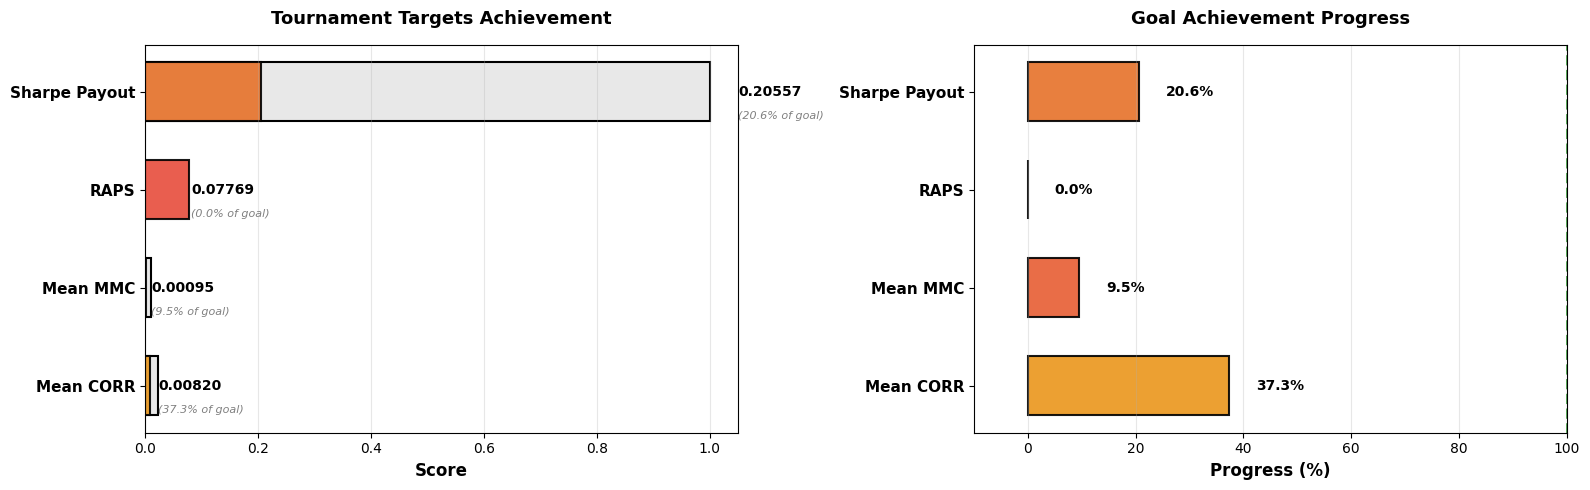

Category,Metric,Value,Goal,Status,Note
Payout,RAPS,+0.0777,+0,✅ MET,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),+0.00095,+0.01,🔴 BELOW,Uniqueness vs benchmark (2× NMR multiplier)
Payout,Mean CORR,+0.00820,+0.022,🔴 BELOW,Official Numerai correlation score (0.5× multiplier)
Risk,Sharpe Ratio,+0.6361,+1,🟠 LAGGING,Risk-adjusted return consistency
Risk,Payout Sharpe,+0.2056,+1,🔴 BELOW,Sharpe ratio of payout proxy (0.5×CORR + 2×MMC)
Risk,MMC Volatility,0.01159,—,—,Standard deviation of era-by-era MMC
Risk,Max Drawdown,-0.13532,-0.05,🟡 CLOSE,Worst sustained CORR cumulative loss
Quality,Mean FNC,-0.00107,+0,🔴 BELOW,CORR after removing linear feature exposure
Quality,Win Rate,74.6%,+0.55,✅ MET,Fraction of eras with positive CORR
Uniqueness,P95 Max Feature Exposure,0.3983,+0.2,🔴 EXCEEDED,95th percentile of strongest single-feature correlation


In [74]:
# 1. Rank-normalize the meta-predictions by era to ensure they are in the (0, 1) range
# This is a critical step before scoring in the Numerai tournament
final_predictions_ranked = rank_by_era(meta_preds, val_eras)

# 2. Build a validation frame for metrics API (expects era, prediction, target, and features)
val_eval_df = validation_clean.loc[meta_y_val.index, ["era"] + feature_set + [MAIN_TARGET]].copy()
val_eval_df["prediction"] = final_predictions_ranked

# 3. Calculate comprehensive Numerai metrics using the updated utility signature
meta_learner_metrics, meta_learner_per_era = calculate_metrics(
    df_validation=val_eval_df,
    benchmarks=val_benchmarks,
    features=feature_set,
    target_col=MAIN_TARGET,
)

# 4. Display the results in a structured table as seen in v0.3
print("--- Ridge Meta-Learner Performance Metrics ---")
display_metrics_table(meta_learner_metrics)

In [76]:
import numpy as np
import pandas as pd
from numerai_tools.scoring import neutralize

# --- VERSION 1: Simple Era-wise Centering ---
def neutralize_version_1(preds, eras):
    """Simple era-wise centering and ranking."""
    tmp = pd.DataFrame({
        "era": eras,
        "prediction": preds
    })
    # Center predictions per era and rank them
    neutralized = tmp.groupby("era")["prediction"].transform(lambda x: (x - x.mean()).rank(pct=True, method="first"))
    return neutralized.values

# --- VERSION 2: Manual Linear Orthogonalization ---
def neutralize_version_2(df, feature_cols, pred_col, proportion=0.5):
    """Manual implementation of linear neutralization (Orthogonalization)."""
    def _neutralize_block(block):
        scores = block[pred_col].to_numpy(dtype=float, copy=True).reshape(-1, 1)
        exposures = block[feature_cols].to_numpy(dtype=float, copy=True)
        
        # Center scores and exposures
        scores -= scores.mean()
        exposures -= exposures.mean(axis=0)
        
        # Linear Regression / Orthogonalization
        # neutralized = scores - proportion * (exposures @ (pinv(exposures) @ scores))
        exposure_pinv = np.linalg.pinv(exposures)
        correction = exposures.dot(exposure_pinv.dot(scores))
        neutralized_scores = scores - (proportion * correction)
        
        return pd.Series(neutralized_scores.flatten(), index=block.index)

    return df.groupby("era", group_keys=False).apply(_neutralize_block)

# --- VERSION 3: Official numerai-tools implementation ---
def neutralize_version_3(df, feature_cols, pred_col, proportion=0.5):
    """Wrapper for the official numerai-tools neutralization."""
    return df.groupby("era", group_keys=False).apply(
        lambda d: neutralize(d[[pred_col]], d[feature_cols], proportion=proportion)
    )

In [78]:
# --- EXECUTION & COMPARISON ---

# Setup analysis dataframe
val_analysis = validation_clean.loc[meta_y_val.index].copy()
val_analysis["prediction"] = meta_preds

# Calculate variants
val_analysis["v1_centered"] = neutralize_version_1(
    val_analysis["prediction"].values, 
    val_analysis["era"].values
)

# Testing the 50% neutralization baseline
val_analysis["v2_linear_05"] = neutralize_version_2(
    val_analysis, feature_set, "prediction", proportion=0.5
)

# Version 3: Testing varying strengths (Aggressive 1.0 vs Light 0.25)
for p in [0.25, 0.75, 1.0]:
    col_name = f"v3_neutral_{int(p*100)}"
    # numerai-tools expects a DataFrame for predictions
    neutralized = val_analysis.groupby("era", group_keys=False).apply(
        lambda d: neutralize(d[["prediction"]], d[feature_set], proportion=p)
    )
    val_analysis[col_name] = neutralized.values

# --- GENERATE METRICS ---
results = {}
eval_cols = ["prediction", "v1_centered", "v2_linear_05", "v3_neutral_25", "v3_neutral_75", "v3_neutral_100"]

for col in eval_cols:
    # calculate_metrics requires era + full feature_set + target + prediction
    eval_df = val_analysis[["era"] + feature_set + [MAIN_TARGET]].copy()
    # IMPORTANT: Always rank-normalize before scoring CORR
    eval_df["prediction"] = val_analysis.groupby("era")[col].rank(pct=True, method="first")
    
    metrics, _ = calculate_metrics(
        df_validation=eval_df,
        benchmarks=val_benchmarks,
        features=feature_set,
        target_col=MAIN_TARGET,
    )
    results[col] = metrics

# Final summary table
comparison_df = pd.DataFrame(results).T
display(comparison_df.sort_values("1_RAPS", ascending=False))

,1_RAPS,2_Sharpe_Payout,3_Mean_CORR,4_Mean_MMC,5_Sharpe_CORR,6_Mean_FNC,7_Max_Drawdown_CORR,8_Win_Rate,9_Feature_Exposure_P95,10_Benchmark_Corr,11_MMC_Volatility,12_Max_Feature_Exposure,13_MMC_SNR,14_MMC_Std,15_MMC_Autocorr
prediction,0.077686,0.205571,0.008197,0.000954,0.636136,-0.001074,-0.135318,0.745856,0.398263,0.282540,0.011587,0.415446,0.082311,0.011587,0.575583
v1_centered,0.077686,0.205571,0.008197,0.000954,0.636136,-0.001074,-0.135318,0.745856,0.398263,0.282540,0.011587,0.415446,0.082311,0.011587,0.575583
v2_linear_05,0.077686,0.205571,0.008197,0.000954,0.636136,-0.001074,-0.135318,0.745856,0.398263,0.282540,0.011587,0.415446,0.082311,0.011587,0.575583
v3_neutral_25,0.077686,0.205571,0.008197,0.000954,0.636136,-0.001074,-0.135318,0.745856,0.398263,0.282540,0.011587,0.415446,0.082311,0.011587,0.575583
v3_neutral_75,0.077686,0.205571,0.008197,0.000954,0.636136,-0.001074,-0.135318,0.745856,0.398263,0.282540,0.011587,0.415446,0.082311,0.011587,0.575583
v3_neutral_100,-0.182923,-0.050572,-0.000117,-0.000723,-0.009188,-0.000726,-0.206643,0.497238,0.970611,0.021449,0.011880,0.978486,-0.060862,0.011880,-0.013558


In [80]:
# --- WRAP-UP: RECORD PERFORMANCE, COMPARE, TRAIN ALL DATA, EXPORT ---
from pathlib import Path
import cloudpickle

# 1) Select best validation variant from the neutralization comparison
best_variant = comparison_df["1_RAPS"].astype(float).idxmax()
best_metrics = results[best_variant]
print(f"Best validation variant by 1_RAPS: {best_variant}")

# 2) Record and compare this run with historical models
model_name = f"ridge_meta_{best_variant}_v0.5"
notebook_name = Path(globals().get("__vsc_ipynb_file__", "finance_arena_v0.5.ipynb")).stem

history_df, current_run = record_model_metrics(
    metrics=best_metrics,
    model_name=model_name,
    notebook_name=notebook_name,
)

leaderboard_df, is_top = compare_top_models_with_current(
    current_run_id=current_run["run_id"],
    top_n=5,
    show_message=True,
)

print("\nMODEL LEADERBOARD (Top 5 + Current)")
display_df = leaderboard_df.copy()
for col, digits in {"mean_mmc": 6, "mean_corr": 6, "raps": 4, "sharpe_payout": 4}.items():
    if col in display_df.columns:
        display_df[col] = display_df[col].astype(float).round(digits)
display(display_df)

# 3) Train production models on ALL available historical data (train + full validation)
print("\n" + "=" * 80)
print("PRODUCTION STAGE: TRAINING ON ALL AVAILABLE DATA")
print("=" * 80 + "\n")

columns_to_keep = ["era"] + feature_set + ALL_TARGETS
full_validation = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"),
    columns=columns_to_keep,
    )
full_data = pd.concat([train[columns_to_keep], full_validation[columns_to_keep]], ignore_index=True)
full_data = full_data.dropna(subset=TARGETS_TO_TRAIN + [MAIN_TARGET]).copy()

print(f"Full production data shape: {full_data.shape}")
print(f"Specialists to train       : {len(TARGETS_TO_TRAIN)}")

# Train one specialist per auxiliary target on full data
prod_specialists = {}
for target_name in tqdm.tqdm(TARGETS_TO_TRAIN, desc="Production specialists"):
    specialist = Ridge(alpha=1.0e-6, random_state=42)
    specialist.fit(full_data[feature_set].values, full_data[target_name].values)
    prod_specialists[target_name] = specialist

# Build production meta-features in-sample and fit final meta-learner
prod_meta_X = pd.DataFrame({
    name: model.predict(full_data[feature_set].values)
    for name, model in prod_specialists.items()
}, index=full_data.index)
prod_meta_y = full_data[MAIN_TARGET].values

prod_meta_learner = Ridge(alpha=1.0e-6, random_state=42)
prod_meta_learner.fit(prod_meta_X.values, prod_meta_y)
print("Production specialists and meta-learner trained.")

# 4) Export cloudpickle prediction pipeline
selected_variant = best_variant

def predict(live_features: pd.DataFrame, live_benchmark_models: pd.DataFrame) -> pd.DataFrame:
    # Build specialist predictions
    specialist_live_X = pd.DataFrame({
        name: model.predict(live_features[feature_set].values)
        for name, model in prod_specialists.items()
    }, index=live_features.index)

    # Meta prediction
    raw_preds = prod_meta_learner.predict(specialist_live_X.values)
    pred_df = pd.DataFrame({"prediction": raw_preds}, index=live_features.index)
    pred_df["era"] = live_features["era"].values

    # Variant-specific post-processing chosen by validation performance
    if selected_variant == "v1_centered":
        pred_df["prediction"] = pred_df.groupby("era")["prediction"].transform(
            lambda x: x - x.mean()
        )
    elif selected_variant in ["v2_linear_05", "v3_neutral_25", "v3_neutral_75", "v3_neutral_100"]:
        proportion_map = {
            "v2_linear_05": 0.5,
            "v3_neutral_25": 0.25,
            "v3_neutral_75": 0.75,
            "v3_neutral_100": 1.0,
        }
        neutralize_prop = proportion_map[selected_variant]

        def _neutralize_block(block):
            scores = block["prediction"].to_numpy(dtype=float, copy=True).reshape(-1, 1)
            exposures = block[feature_set].to_numpy(dtype=float, copy=True)
            scores -= scores.mean()
            exposures -= exposures.mean(axis=0)
            correction = exposures.dot(np.linalg.pinv(exposures).dot(scores))
            neutralized = scores - neutralize_prop * correction
            return pd.Series(neutralized.flatten(), index=block.index)

        tmp = pred_df.join(live_features[feature_set])
        pred_df["prediction"] = tmp.groupby("era", group_keys=False).apply(_neutralize_block)

    # Always rank-normalize by era for submission
    pred_df["prediction"] = pred_df.groupby("era")["prediction"].rank(pct=True, method="first")
    return pred_df[["prediction"]]

export_name = f"finance_arena_v0_5_{best_variant}.pkl"
with open(export_name, "wb") as f:
    cloudpickle.dump(predict, f)

print(f"\nExport complete: {export_name}")

Best validation variant by 1_RAPS: prediction



MODEL LEADERBOARD (Top 5 + Current)


,rank,model_name,run_id,mean_mmc,mean_corr,raps,sharpe_payout,timestamp_utc,is_current
0,1,ridge_meta_prediction_v0.5,2bf11109,0.000954,0.008197,0.0777,0.2056,2026-03-20 19:20:42,True
1,2,lgbm_ensemble_v0.3,52f4b2df,0.000512,0.011083,0.1332,0.2416,2026-03-07 16:38:46,False
2,3,ridge_meta_ensemble_v0.3.2,53bf770c,-0.000157,0.012040,0.0998,0.2112,2026-03-19 20:45:56,False
3,4,1_hello_numerai_modified,c7fae6f9,-0.000914,0.012383,0.0774,0.1610,2026-03-01 21:40:09,False
4,5,finance_arena_v0.1,2c663abc,-0.001063,0.012799,0.0383,0.1598,2026-03-01 22:05:13,False



PRODUCTION STAGE: TRAINING ON ALL AVAILABLE DATA

Full production data shape: (6567955, 61)
Specialists to train       : 17


Production specialists: 100%|██████████| 17/17 [00:31<00:00,  1.87s/it]


Production specialists and meta-learner trained.

Export complete: finance_arena_v0_5_prediction.pkl
